# Numerical Analysis Project 1
##  Authors: Bopeng Zhang (bz292), Daniel Chuang (dc863), Tianrui Wang (tw559)

In [ ]:
import numpy as np
import random
from typing import *
import matplotlib.pyplot as plt

## Goal 1:
Implement the Householder scheme for computing QR factorizations. Your QR factorization routine should take in a $n \times k$ matrix $B$ with $k\leq n$ and returns a $n\times k$ matrix $Q$ with orthonormal columns (or sufficient information to be able to apply it to a vector, e.g., the Householder vectors), and a $k\times k$ upper triangular matrix $R.$ Please demonstrate that your algorithm behaves as expected (this means both that you are getting a valid QR factorization as output and that it achieves the desired computational scaling). Demonstrate that your implementation achieves the expected scaling and explain how you tested your implementation.

In [51]:
import numpy as np
from typing import Tuple

def QR_Householder_helper(A: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Helper function for the QR algorithm
    Args:
        A (ndarray): The matrix being decomposed
    Outputs:
        Tuple(ndarray, ndarray): A (matrix that has the Householder vectors),
        tau (Scaling factors for the Householder reflections)
    """
    m, n = A.shape
    A = A.copy()
    tau = np.zeros(n)
    
    for j in range(n):
        # Extract the j-th column vector (starting from diagonal element)
        x = A[j:, j]
        normx = np.linalg.norm(x)
        
        if normx < 1e-14:  # avoid div by 0!
            continue
            
        s = -np.sign(A[j, j])
        s = -1 if A[j, j] == 0 else s
        u1 = A[j, j] - s * normx
        
        # Compute Householder vector
        w = x / u1
        w[0] = 1.0
        
        if j + 1 < m:
            A[j+1:, j] = w[1:]
        
        A[j, j] = s * normx
        tau[j] = -s * u1 / normx
        
        # Apply Householder reflection to remaining columns
        if j + 1 < n:  # columns to update?
            # More efficient way to compute the outer product update
            wTA = w @ A[j:, j+1:]
            A[j:, j+1:] -= tau[j] * np.outer(w, wTA)
            
    return A, tau


def form_Q(A_mod: np.ndarray, tau: np.ndarray) -> np.ndarray:
    """
    Form the Q matrix from the Householder reflectors stored in A_mod and tau
    Args:
        A_mod (ndarray): A matrix that has Householder vectors
        tau (ndarray): Scaling factors for Householder reflections
    Output:
        Q (ndarray): orthog Q
    """
    m, n = A_mod.shape
    Q = np.eye(m, n)
    
    for j in range(n-1, -1, -1):
        # Skip if no reflection was applied
        if abs(tau[j]) < 1e-14:
            continue
            
        # Extract HH vec
        w = np.zeros(m - j)
        w[0] = 1.0
        
        if j + 1 < m:
            w[1:] = A_mod[j+1:, j]
            
        # Apply HH reflection to Q
        wTQ = w @ Q[j:, :]
        Q[j:, :] -= tau[j] * np.outer(w, wTQ)
        
    return Q


def extract_R(A_mod: np.ndarray) -> np.ndarray:
    """
    Extract the R matrix from the modified A matrix.
    Args:
        A_mod (ndarray): Modified A matrix containing the Householder vectors
    Output:
        R (ndarray): The upper triangular matrix R
    """
    m, n = A_mod.shape
    R = np.zeros((n, n))
    
    for i in range(n):
        R[i, i:] = A_mod[i, i:]
        
    return R


def QR_Householder(A: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute a reduced QR factorization for matrix A via Householder reflections
    Args:
        A (ndarray): n x k, Input matrix with k <= n
    Output:
        Q (ndarray): n x k, orthog
        R (ndarray): k x k, upper triangular
    """
    A_mod, tau = QR_Householder_helper(A)
    Q = form_Q(A_mod, tau)
    R = extract_R(A_mod)
    
    return Q, R

In [52]:
# Goal 1 Test Cases
for k in range(1, 10):
  for n in range(k, 10):
    A = np.random.rand(5, 3)
    Q_hh, R_hh = QR_Householder(A)
    Q, R = np.linalg.qr(A, mode="reduced")
    assert(np.allclose(Q_hh @ R_hh, A))
    assert(np.allclose(Q_hh, Q))
    assert(np.allclose(R_hh, R))
print("All test cases passed")

All test cases passed


## Goal 2:
Using your $QR$ factorization, implement Algorithm 1. This is written as a matrix least squares problem, but think about the Frobenius norm and how you might be able to split it up into problems we know how to solve. **Please explain how you do this in the project report.** Practically, it is possible to then block some of these operations together for efficiency; you may take advantage of this if you wish.

In [53]:
# We will solve this by four steps
# 1. Backsolver for triangular
# 2. Matrix case
# 3. Implement Alternating LS

# Backsub following from Bindel's notes
# https://www.cs.cornell.edu/courses/cs4220/2023sp/lec/2023-02-08.pdf
def backward_subst(R, Qt_b):
    """Backward substitution for QR

    Args:
        R (ndarray): Upper Triangular
        Qt_b (ndarray): Intermediate value from orthog Q.T times b

    Output:
        x (ndarray): Our solution to the linear system

    """
    n = Qt_b.shape[0]
    x = np.copy(Qt_b)
    for i in range(n-1, -1, -1):
      x[i] = (x[i] - np.sum(R[i, i+1:n] * x[i+1:n])) / R[i, i]
    return x

def vector_ls(A, b):
    """Vector Least Squares Solver

    Args:
        A (ndarray): Model
        b (ndarray): Ground truth vector
    
    Output:
        x (ndarray): Solution x
    
    """
    Q, R = QR_Householder(A)
    return backward_subst(R, Q.T @ b)

def matrix_ls(A, B):
    """
    Matrix Least Squares Solver via QR factorization.
    Solves the problem: min ||A·X - B||_F
    
    Args:
        A (ndarray): m×n matrix, m >= n
        B (ndarray): m×p matrix
        
    Returns:
        X (ndarray): n×p solution matrix
    """
    m, n = A.shape
    p = B.shape[1]
    
    Q, R = QR_Householder(A)
    
    X = np.zeros((n, p))
    
    for j in range(p):
        y = Q.T @ B[:, j]
        X[:, j] = backward_subst(R, y[:n])
    return X

def alternating_ls(A, k, num_iterations=9999, tol=1e-2):
    """Implementation of Algorithm 1
    
    Args:
        A (ndarray): our n1 by n2 image
        k (int): rank we want
        num_iterations (int): max iterations
        tol (int): convergence tolerance

    """
    n1, n2 = A.shape
    W = np.random.randn(n1,k)
    Z = np.random.randn(n2,k)

    prev_error = np.linalg.norm(A - W @ Z.T, 'fro')
    for i in range(num_iterations):
        Z = matrix_ls(W, A).T
        W = matrix_ls(Z, A.T).T

        current_error = np.linalg.norm(A - W @ Z.T, 'fro')
        print(current_error)
        error_change = abs(prev_error - current_error)
        if error_change < tol:
            print(f"Converged after {i+1} iterations")
            break
            
        prev_error = current_error

    return W @ Z.T

In [54]:
# Test backward_sub
for k in range(1, 10):
    for n in range(k, 10):
        U = np.triu(np.random.rand(n, n))
        for i in range(n):
            if abs(U[i, i]) < 1e-10:
                U[i, i] = 1.0
        d = np.random.rand(n)
        x_our = backward_subst(U, d)
        x_numpy = np.linalg.solve(U, d)
        assert np.allclose(x_our, x_numpy)
        assert np.allclose(U @ x_our, d)
print("All backward substitution tests passed!")

# Test vector LS
for n in range(2, 20):
    m = random.randint(n, n + 3)
    A = np.random.rand(m, n)
    b = np.random.rand(m)
    x_our = vector_ls(A, b)
    x_numpy = np.linalg.lstsq(A, b)[0]
    assert(np.allclose(x_our, x_numpy))  
print("All vector ls tests passed!")

All backward substitution tests passed!
All vector ls tests passed!


/var/folders/rp/nchg416j6b37gngjnnhbxrsc0000gp/T/ipykernel_18192/1679836725.py:21: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x_numpy = np.linalg.lstsq(A, b)[0]


## Goal 3:
Using your implementation, load the file Cornell.csv which has an image stored in the matrix $C$ and try to compute the best rank 75 approximation of the image. Compare this with the result of the best rank 75 image from the SVD (you can use a built in routine to compute this), what do you observe qualitatively and quantitatively?

In [43]:
def load_image(filename):
  A = np.loadtxt(open(filename, "rb"), delimiter=",", skiprows=1)
  return A

def als_svd_approximations(filename):
  A = load_image(filename)

  # Our approx
  A_apprx = alternating_ls(A, k=75)

  # SVD
  U, S, Vt = np.linalg.svd(A, full_matrices=False)
  k = 75
  U_k = U[:, :k]
  S_k = S[:k]
  Vt_k = Vt[:k, :]
  A_svd = U_k @ np.diag(S_k) @ Vt_k

  # Calculate the Frobenius difference
  frob_diff = np.linalg.norm(A_apprx - A_svd, "fro")
  print("The Frobenius Difference is: ", frob_diff)

  return A_apprx, A_svd

A_approx, A_svd = als_svd_approximations("data/Cornell.csv")
  

129.67840030894453
89.07080349619825
85.60711748876598
84.79461942060146
84.49215739806023
84.33906037341609
84.24375637174991
84.17646559008215
84.12573085056049
84.08623165165247
84.05487864640978
84.0295697672497
84.00879509507149
83.99147182167569
83.9768326973634
83.96433524074398
83.9535906426789
83.94431212446037
Converged after 18 iterations
The Frobenius Difference is:  20.733096830265392


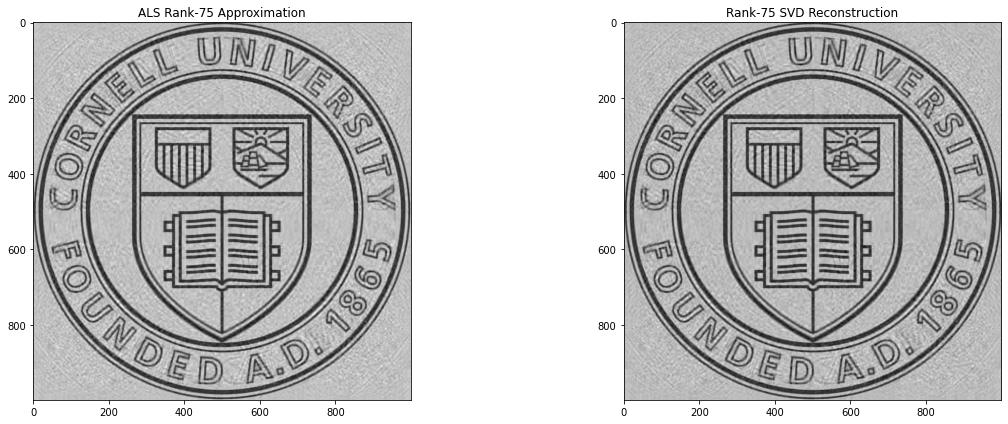

In [55]:
def compare_images(A, B, A_title, B_title):
  fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 1 row, 3 columns

  axes[0].imshow(A, cmap='gray')
  axes[0].set_title(A_title)
  axes[0].axis('on')

  axes[1].imshow(B, cmap='gray')
  axes[1].set_title(B_title)
  axes[1].axis('on')
  
  # Adjust layout to prevent overlap
  plt.tight_layout()

  # Show the combined figure
  plt.show()

compare_images(A_approx, A_svd, "ALS Rank-75 Approximation", 'Rank-75 SVD Reconstruction')
  

## Question 1:
Show that if we want to solve $$\min_x \|Ax-b\|_2^2 + \beta^2 \|x\|_2^2$$ we can instead solve 
$$
\min_x \left\|\begin{bmatrix}A \\ \beta I\end{bmatrix}x-\begin{bmatrix}b \\ 0\end{bmatrix}\right\|_2^2.
$$

In [56]:
def reg_solver(A, b, beta):
    n = A.shape[1]
    A_aug = np.vstack([A, beta * np.eye(n)])
    b_aug = np.concatenate([b, np.zeros(n)])
    return vector_ls(A_aug, b_aug)

## Goal 4:
Using your $QR$ factorization, implement Algorithm 2. From the first set of goals, you should have worked out how to split this up into solving many least squares problems. Now, you have to think about what size those problems are, and which entries of the matrices they involve. Given that, you can then leverage your $QR$ factorization and the preceding item to implement the algorithm. **Please explain how you do this in the project report.**

In [ ]:
def compute_masked_error(A: np.ndarray, mask: np.ndarray, W: np.ndarray, Z: np.ndarray) -> float:
    """
    Compute the Frobenius norm of the error on observed entries.
    """
    error = A - W @ Z.T
    
    return np.linalg.norm(error[mask])

def alternating_ls_missing(A: np.ndarray, Omega: np.ndarray, k: int, beta: float,
                           num_iterations: int = 1000, tol: float = 1e-2) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Algorithm 2 implementation
    
    Args:
      A: (n1 x n2) data matrix.
      Omega: Boolean matrix of the same shape as A; True indicates an observed entry
      k: Target rank
      beta: Regularization param
      num_iterations: Maximum iterations
      tol: Tolerance for convergence
    
    Returns:
      reconstruction and errors
    """
    n1, n2 = A.shape
    W = np.random.randn(n1, k)
    Z = np.random.randn(n2, k)
    errors = []
    
    prev_error = compute_masked_error(A, Omega, W, Z)
    
    for it in range(num_iterations):
        # Update Z (for each column j of A)
        for j in range(n2):
            observed_rows = Omega[:, j]
            if np.sum(observed_rows) == 0:
                continue  # Check if column has any non zeros
            W_obs = W[observed_rows, :]
            A_obs = A[observed_rows, j]
            z = reg_solver(W_obs, A_obs, beta)
            Z[j, :] = z

        for i in range(n1):
            observed_cols = Omega[i, :]
            if np.sum(observed_cols) == 0:
                continue
            Z_obs = Z[observed_cols, :]
            A_obs = A[i, observed_cols]
            w = reg_solver(Z_obs, A_obs, beta)
            W[i, :] = w
        
        current_error = compute_masked_error(A, Omega, W, Z)
        print(f"Iteration {it+1}: error = {current_error}")
        errors.append(current_error)
        if abs(prev_error - current_error) < tol:
            print(f"Converged after {it+1} iterations")
            break
        prev_error = current_error

    return (W @ Z.T, errors)

## Goal 5:
Using your implementation, load each of the image files in Image*.csv and associated masks Mask*.csv, where * is 1, 2, and 3. Each file contains an image and the associated mask file contains an image of the same size whose entries are 1 if the corresponding entry of $C$ is observed and 0 if it is unobserved (so it defines the set $\Omega$). The unknown entries of $C$ have been set arbitrarily and you should not access or use them (as the will adversely affect your results). Using Algorithm 2, try and recover each of the underlying images. You now have some parameters to consider and we encourage exploration of their values. You should not have to go to $k$ larger than 75 for any of the examples, and good $\beta$ to try are between $10^{-2}$ and 1. Report the images you recover, and discuss what you observe.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def load_image(filename):
    # Load image data
    return np.loadtxt(open(filename, "rb"), delimiter=",", skiprows=1)

def load_mask(filename):
    Omega = np.loadtxt(open(filename, "rb"), delimiter=",", skiprows=1)
    return Omega.astype(bool)

def als_recovery(A, Omega, k=10, beta=0.1):
    A_apprx, errors = alternating_ls_missing(A, Omega, k=k, beta=beta, num_iterations=10, tol=0.5)
    return A_apprx, errors

def parameter_sweep():
    image_num = 1
    A = load_image(f"data/Image{image_num}.csv")
    Omega = load_mask(f"data/Mask{image_num}.csv")
    
    # Define parameter ranges
    betas = [0.01, 0.1, 1.0]
    ranks = [10, 20, 30]
    
    # Initialize results storage
    error_histories = {}
    final_errors = []
    
    # Run parameter sweep
    for beta in betas:
        for k in ranks:
            print(f"Running with beta={beta}, rank={k}")
            _, errors = als_recovery(A, Omega, k=k, beta=beta)
            error_histories[(beta, k)] = errors
            final_errors.append({'beta': beta, 'rank': k, 'error': errors[-1]})
    
    # Plot convergence for each parameter combination
    plt.figure(figsize=(15, 10))
    for i, ((beta, k), errors) in enumerate(error_histories.items()):
        plt.subplot(len(betas), len(ranks), i + 1)
        plt.plot(errors)
        plt.title(f'β={beta}, k={k}')
        plt.xlabel('Iteration')
        plt.ylabel('Error')
        plt.grid(True)
    
    plt.tight_layout()
    plt.suptitle('Convergence Behavior for Different Parameters', fontsize=16)
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Plot error by parameter values
    plt.figure(figsize=(12, 8))
    
    # Plot by beta
    plt.subplot(1, 2, 1)
    for beta in betas:
        beta_results = [r for r in final_errors if r['beta'] == beta]
        beta_results.sort(key=lambda x: x['rank'])
        plt.plot([r['rank'] for r in beta_results],
                 [r['error'] for r in beta_results],
                 marker='o', label=f'Beta={beta}')
    
    plt.xlabel('Rank')
    plt.ylabel('Final Error')
    plt.title('Final Error vs Rank for Different Beta Values')
    plt.legend()
    plt.grid(True)
    
    # Plot by rank
    plt.subplot(1, 2, 2)
    for k in ranks:
        rank_results = [r for r in final_errors if r['rank'] == k]
        rank_results.sort(key=lambda x: x['beta'])
        plt.plot([r['beta'] for r in rank_results],
                 [r['error'] for r in rank_results],
                 marker='o', label=f'Rank={k}')
    
    plt.xlabel('Beta')
    plt.ylabel('Final Error')
    plt.title('Final Error vs Beta for Different Ranks')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Plot all convergence curves in one graph for comparison
    plt.figure(figsize=(10, 6))
    for (beta, k), errors in error_histories.items():
        plt.plot(errors, label=f'β={beta}, k={k}')
    
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    plt.title('Convergence Comparison Across All Parameter Settings')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return final_errors

# Run the parameter sweep
if __name__ == "__main__":
    results = parameter_sweep()

Running with beta=0.01, rank=10
Iteration 1: error = 72.17241463674735
Iteration 2: error = 33.66353936754243
Iteration 3: error = 30.473354845288107
Iteration 4: error = 29.297532099548334
Iteration 5: error = 28.786849214218016
Iteration 6: error = 28.50057560143355
Converged after 6 iterations
Running with beta=0.01, rank=20
Iteration 1: error = 64.26740307568521
Iteration 2: error = 29.29976959413541
Iteration 3: error = 25.702417559111723
Iteration 4: error = 24.270343039569564
Iteration 5: error = 23.517669214543787
Iteration 6: error = 23.0617574845943
Converged after 6 iterations
Running with beta=0.01, rank=30
Iteration 1: error = 51.2709171637581
Iteration 2: error = 25.83492440013993
Iteration 3: error = 22.080986311406246
Iteration 4: error = 20.452529082120783
Iteration 5: error = 19.538877682262655
Iteration 6: error = 18.977830480924695
Iteration 7: error = 18.604398812441
Converged after 7 iterations
Running with beta=0.1, rank=10
Iteration 1: error = 62.52895936975618
